In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Data (1).csv")

print("Data shape:", df.shape)

df.head()

Data shape: (377719, 7)


,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
0,01-01-2017 00:00,867.63,910.42,-189.54,-186.04,852.13,-145.9
1,01-01-2017 00:05,879.23,918.14,-184.33,-182.1,862.53,-149.76
2,01-01-2017 00:10,875.67,924.18,-181.26,-166.47,866.06,-145.01
3,01-01-2017 00:15,875.28,923.15,-179.15,-174.83,865.85,-142.82
4,01-01-2017 00:20,891.66,934.26,-178.32,-173.72,876.06,-143.39


In [4]:
df.head()

,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
0,01-01-2017 00:00,867.63,910.42,-189.54,-186.04,852.13,-145.9
1,01-01-2017 00:05,879.23,918.14,-184.33,-182.1,862.53,-149.76
2,01-01-2017 00:10,875.67,924.18,-181.26,-166.47,866.06,-145.01
3,01-01-2017 00:15,875.28,923.15,-179.15,-174.83,865.85,-142.82
4,01-01-2017 00:20,891.66,934.26,-178.32,-173.72,876.06,-143.39


In [5]:
df.tail()

,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
377714,08-07-2020 11:55,899.42,919.79,-224.07,-209.77,901.01,-175.15
377715,08-07-2020 12:00,879.9,895.02,-228.04,-211.28,878.08,-176.94
377716,08-07-2020 12:05,887.2,895.7,-230.11,-214.65,885.32,-179.18
377717,08-07-2020 12:10,908.5,916.33,-231.51,-218.09,906.2,-181.96
377718,08-07-2020 12:15,880.86,905.31,-235.02,-219.44,882.1,-184.02


In [6]:
df.columns


Index(['time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp',
       'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft',
       'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft'],
      dtype='str')

In [7]:
df.dtypes


time                        str
Cyclone_Inlet_Gas_Temp      str
Cyclone_Material_Temp       str
Cyclone_Outlet_Gas_draft    str
Cyclone_cone_draft          str
Cyclone_Gas_Outlet_Temp     str
Cyclone_Inlet_Draft         str
dtype: object

In [8]:
df.describe()

,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
count,377719,377719,377719,377719,377719,377719,377719
unique,377719,39736,39662,27669,26487,48044,24010
top,01-01-2017 00:00,Not Connect,0,Not Connect,Not Connect,28.88,Not Connect
freq,1,723,14226,723,723,2036,723


In [9]:
df.isnull().sum()

time                        0
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Define the six sensor parameters
sensor_columns = [
    "Cyclone_Inlet_Gas_Temp",
    "Cyclone_Material_Temp",
    "Cyclone_Outlet_Gas_draft",
    "Cyclone_cone_draft",
    "Cyclone_Gas_Outlet_Temp",
    "Cyclone_Inlet_Draft"
]

# Convert each sensor column from string/object to numeric values
# Invalid values, if any, will be converted to NaN
for col in sensor_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Display the data types after conversion
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
time                            str
Cyclone_Inlet_Gas_Temp      float64
Cyclone_Material_Temp       float64
Cyclone_Outlet_Gas_draft    float64
Cyclone_cone_draft          float64
Cyclone_Gas_Outlet_Temp     float64
Cyclone_Inlet_Draft         float64
dtype: object


In [12]:
# Display basic statistics after converting the sensor columns to numeric
# This helps verify the numerical ranges and identify unusual values

print("Statistical summary of sensor parameters:")
display(df[sensor_columns].describe())

Statistical summary of sensor parameters:


,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
count,376399.000000,376128.000000,376398.000000,376399.000000,376398.000000,376397.000000
mean,727.348549,750.830483,-177.820685,-164.572619,715.759972,-141.302857
std,328.664814,350.921068,99.147236,90.103023,325.346446,77.615576
min,0.000000,-185.000000,-456.660000,-459.310000,13.790000,-396.370000
25%,856.270000,867.667500,-247.190000,-226.770000,801.960000,-193.510000
50%,882.380000,913.360000,-215.260000,-198.560000,871.525000,-169.460000
75%,901.110000,943.660000,-170.130000,-143.640000,899.300000,-136.290000
max,1157.630000,1375.000000,40.270000,488.860000,1375.000000,41.640000


In [13]:
# Check missing values after numeric conversion
# This shows whether any sensor observations became NaN during conversion

print("Missing values after numeric conversion:")
print(df[sensor_columns].isnull().sum())

Missing values after numeric conversion:
Cyclone_Inlet_Gas_Temp      1320
Cyclone_Material_Temp       1591
Cyclone_Outlet_Gas_draft    1321
Cyclone_cone_draft          1320
Cyclone_Gas_Outlet_Temp     1321
Cyclone_Inlet_Draft         1322
dtype: int64


In [14]:
# Display the first few timestamp values
# This helps us understand the format used in the time column

print("First 10 timestamp values:")
print(df["time"].head(10))

# Display the last few timestamp values
# This helps us check whether the format changes later in the dataset

print("\nLast 10 timestamp values:")
print(df["time"].tail(10))

# Check the current data type of the time column
print("\nTime column data type:")
print(df["time"].dtype)

# Count the number of unique timestamp values
# This helps us check whether timestamps are repeated

print("\nNumber of unique timestamps:")
print(df["time"].nunique())

# Check for duplicate timestamp values
print("\nDuplicate timestamps:")
print(df["time"].duplicated().sum())

First 10 timestamp values:
0    01-01-2017 00:00
1    01-01-2017 00:05
2    01-01-2017 00:10
3    01-01-2017 00:15
4    01-01-2017 00:20
5    01-01-2017 00:25
6    01-01-2017 00:30
7    01-01-2017 00:35
8    01-01-2017 00:40
9    01-01-2017 00:45
Name: time, dtype: str

Last 10 timestamp values:
377709    08-07-2020 11:30
377710    08-07-2020 11:35
377711    08-07-2020 11:40
377712    08-07-2020 11:45
377713    08-07-2020 11:50
377714    08-07-2020 11:55
377715    08-07-2020 12:00
377716    08-07-2020 12:05
377717    08-07-2020 12:10
377718    08-07-2020 12:15
Name: time, dtype: str

Time column data type:
str

Number of unique timestamps:
377719

Duplicate timestamps:
0


In [15]:
# Display a few consecutive timestamp records
# This helps us examine whether the timestamps follow a regular sequence

print("Consecutive timestamp records:")
print(df["time"].iloc[:20].to_string(index=True))

# Display a section from the middle of the dataset
# This helps check whether the timestamp format changes later

print("\nMiddle timestamp records:")
middle = len(df) // 2
print(df["time"].iloc[middle:middle + 10].to_string(index=True))

# Display the final timestamp records
# This confirms the ending format of the timestamp column

print("\nFinal timestamp records:")
print(df["time"].tail(10).to_string(index=True))

Consecutive timestamp records:
0     01-01-2017 00:00
1     01-01-2017 00:05
2     01-01-2017 00:10
3     01-01-2017 00:15
4     01-01-2017 00:20
5     01-01-2017 00:25
6     01-01-2017 00:30
7     01-01-2017 00:35
8     01-01-2017 00:40
9     01-01-2017 00:45
10    01-01-2017 00:50
11    01-01-2017 00:55
12    01-01-2017 01:00
13    01-01-2017 01:05
14    01-01-2017 01:10
15    01-01-2017 01:15
16    01-01-2017 01:20
17    01-01-2017 01:25
18    01-01-2017 01:30
19    01-01-2017 01:35

Middle timestamp records:
188859    10/19/2018 18:10
188860    10/19/2018 18:15
188861    10/19/2018 18:20
188862    10/19/2018 18:25
188863    10/19/2018 18:30
188864    10/19/2018 18:35
188865    10/19/2018 18:40
188866    10/19/2018 18:45
188867    10/19/2018 18:50
188868    10/19/2018 18:55

Final timestamp records:
377709    08-07-2020 11:30
377710    08-07-2020 11:35
377711    08-07-2020 11:40
377712    08-07-2020 11:45
377713    08-07-2020 11:50
377714    08-07-2020 11:55
377715    08-07-2020 12:

In [16]:
# Create a separate dataset for the anomaly analysis
# The original dataframe remains unchanged

analysis_df = df.dropna(
    subset=sensor_columns
).copy()

# Display the number of records before and after removing
# records with missing sensor measurements

print("Original number of records:", len(df))
print("Records used for analysis:", len(analysis_df))
print("Records excluded due to missing sensors:", len(df) - len(analysis_df))

Original number of records: 377719
Records used for analysis: 376124
Records excluded due to missing sensors: 1595


In [17]:
# Verify that no missing sensor values remain
# in the dataset that will be used for analysis

print("Missing values in analysis dataset:")
print(analysis_df[sensor_columns].isnull().sum())

Missing values in analysis dataset:
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


In [18]:
# Check the data types of the six sensor parameters
# All sensor columns should be numeric

print("Sensor data types:")
print(analysis_df[sensor_columns].dtypes)

# Check for any remaining missing values
print("\nMissing values:")
print(analysis_df[sensor_columns].isnull().sum())

# Display the shape of the final analysis data
print("\nAnalysis dataset shape:")
print(analysis_df.shape)

Sensor data types:
Cyclone_Inlet_Gas_Temp      float64
Cyclone_Material_Temp       float64
Cyclone_Outlet_Gas_draft    float64
Cyclone_cone_draft          float64
Cyclone_Gas_Outlet_Temp     float64
Cyclone_Inlet_Draft         float64
dtype: object

Missing values:
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64

Analysis dataset shape:
(376124, 7)


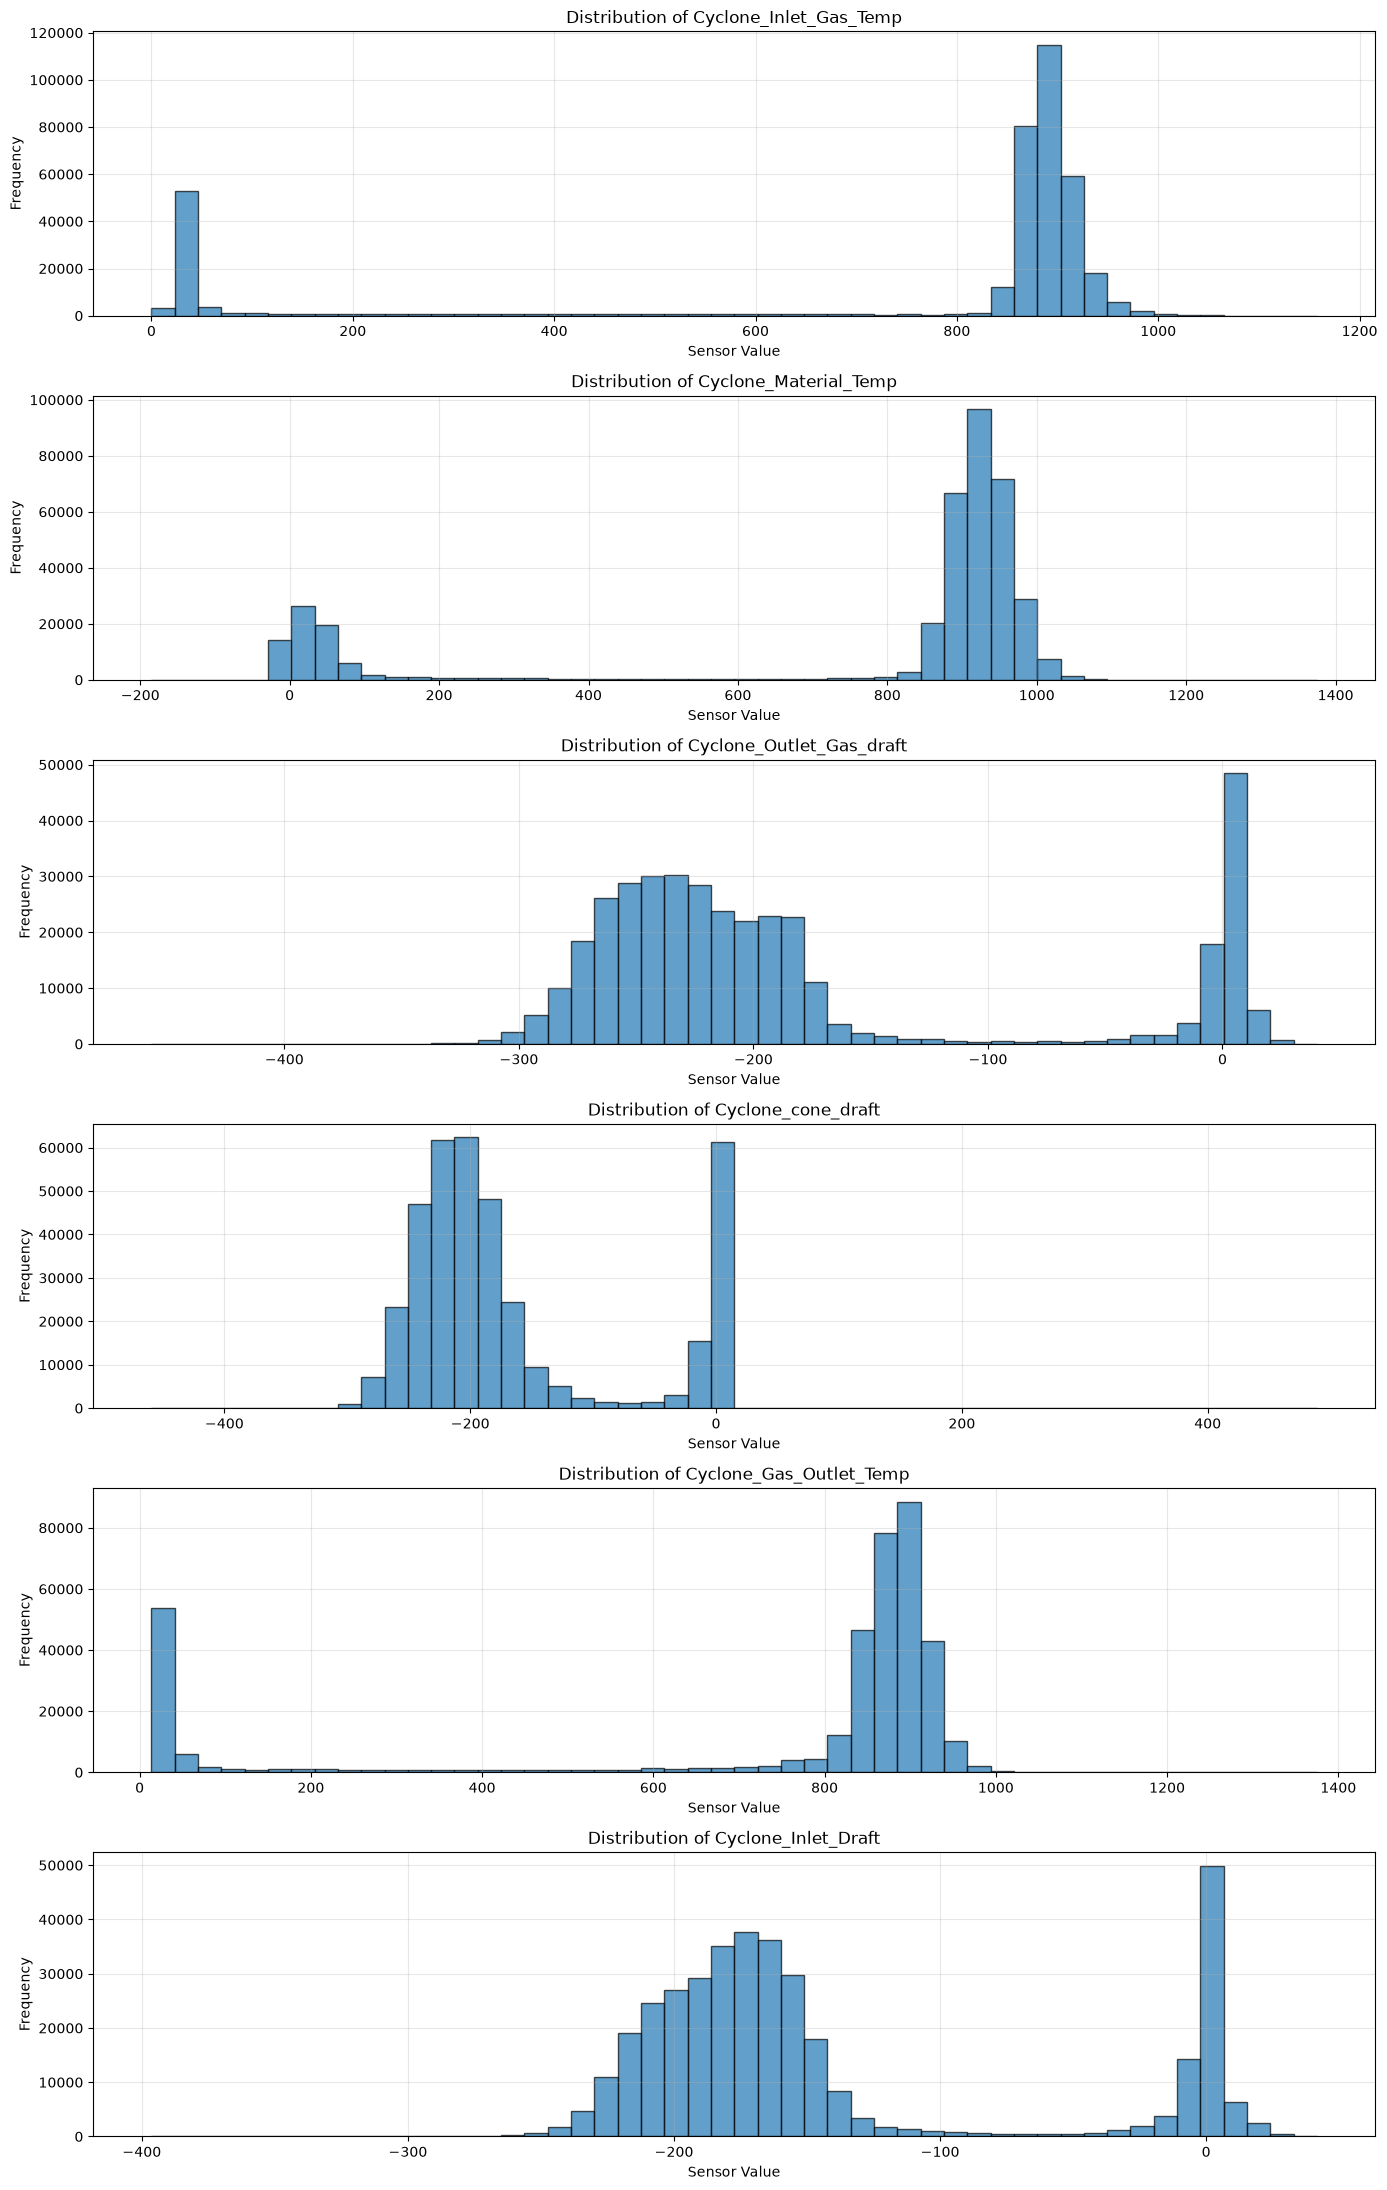

In [19]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create one figure with six histograms
fig, axes = plt.subplots(6, 1, figsize=(14, 22))

# Plot the distribution of each sensor parameter
for ax, col in zip(axes, sensor_columns):

    # Plot the histogram using the available sensor values
    ax.hist(
        analysis_df[col],
        bins=50,
        edgecolor="black",
        alpha=0.7
    )

    # Add the parameter name as the title
    ax.set_title(f"Distribution of {col}")

    # Add axis labels
    ax.set_xlabel("Sensor Value")
    ax.set_ylabel("Frequency")

    # Add grid for easier reading
    ax.grid(True, alpha=0.3)

# Adjust spacing between graphs
plt.tight_layout()

# Display the distributions
plt.show()

In [20]:
# Select the six sensor variables for Isolation Forest
X = analysis_df[sensor_columns]

# Check the shape of the model input
print("Input shape:", X.shape)

# Display the first five rows
X.head()

Input shape: (376124, 6)


,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
0,867.63,910.42,-189.54,-186.04,852.13,-145.90
1,879.23,918.14,-184.33,-182.10,862.53,-149.76
2,875.67,924.18,-181.26,-166.47,866.06,-145.01
3,875.28,923.15,-179.15,-174.83,865.85,-142.82
4,891.66,934.26,-178.32,-173.72,876.06,-143.39


In [21]:
# Import Isolation Forest from scikit-learn
from sklearn.ensemble import IsolationForest

# Create the Isolation Forest model
model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

# Display the model configuration
print(model)

IsolationForest(contamination=0.01, random_state=42)


In [22]:
# Train the Isolation Forest model using the six sensor variables
model.fit(X)

# Confirm that the model has been trained
print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [24]:
# Predict whether each observation is normal or anomalous
predictions = model.predict(X)

# Display the first 20 predictions
print(predictions[:50])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [25]:
# Store the Isolation Forest prediction in the dataframe
analysis_df["anomaly"] = predictions

# Display the first five rows
analysis_df.head()

,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft,anomaly
0,01-01-2017 00:00,867.63,910.42,-189.54,-186.04,852.13,-145.90,1
1,01-01-2017 00:05,879.23,918.14,-184.33,-182.10,862.53,-149.76,1
2,01-01-2017 00:10,875.67,924.18,-181.26,-166.47,866.06,-145.01,1
3,01-01-2017 00:15,875.28,923.15,-179.15,-174.83,865.85,-142.82,1
4,01-01-2017 00:20,891.66,934.26,-178.32,-173.72,876.06,-143.39,1


In [26]:
# Count how many observations are classified as normal and anomalous
print("Normal observations:", (predictions == 1).sum())
print("Anomalous observations:", (predictions == -1).sum())

# Calculate the percentage of anomalies
anomaly_percentage = (predictions == -1).mean() * 100

print("Anomaly percentage:", anomaly_percentage)

Normal observations: 372362
Anomalous observations: 3762
Anomaly percentage: 1.0002020610224287


In [31]:
# Calculate the Isolation Forest anomaly score
# Higher values will indicate observations that are more unusual
anomaly_scores = -model.decision_function(X)

# Add the anomaly score to the analysis dataframe
analysis_df["anomaly_score"] = anomaly_scores

# Display the first five observations with their anomaly scores
print(analysis_df[["time", "anomaly", "anomaly_score"]].head())

               time  anomaly  anomaly_score
0  01-01-2017 00:00        1      -0.288991
1  01-01-2017 00:05        1      -0.290501
2  01-01-2017 00:10        1      -0.276401
3  01-01-2017 00:15        1      -0.273772
4  01-01-2017 00:20        1      -0.269983


In [32]:
# Display the anomaly scores for observations classified as anomalies
print(
    analysis_df.loc[
        analysis_df["anomaly"] == -1,
        ["time", "anomaly_score"]
    ].head(20)
)

                  time  anomaly_score
6363    1/23/2017 2:15       0.004682
6373    1/23/2017 3:05       0.000822
6399    1/23/2017 5:15       0.000883
6408    1/23/2017 6:00       0.000196
6409    1/23/2017 6:05       0.003948
6410    1/23/2017 6:10       0.000075
6419    1/23/2017 6:55       0.021622
6495   1/23/2017 13:15       0.006139
6508   1/23/2017 14:20       0.000066
6509   1/23/2017 14:25       0.018671
6511   1/23/2017 14:35       0.002390
22831   3/21/2017 6:35       0.007720
22833   3/21/2017 6:45       0.014065
22834   3/21/2017 6:50       0.005899
22835   3/21/2017 6:55       0.000621
22836   3/21/2017 7:00       0.004029
22837   3/21/2017 7:05       0.003029
22839   3/21/2017 7:15       0.000769
22933  3/21/2017 15:05       0.013928
22961  3/21/2017 17:25       0.015405


In [33]:
# Create a copy of the anomaly observations
anomalies = analysis_df[analysis_df["anomaly"] == -1].copy()

# Store the original row index so we can identify consecutive observations
anomalies["row_position"] = anomalies.index

# Calculate the gap between consecutive anomalous observations
anomalies["position_gap"] = anomalies["row_position"].diff()

# Start a new group whenever the anomaly is not immediately after the previous anomaly
anomalies["group"] = (anomalies["position_gap"] != 1).cumsum()

# Display the first few grouped anomaly observations
print(
    anomalies[
        ["row_position", "time", "position_gap", "group"]
    ].head(20)
)

       row_position             time  position_gap  group
6363           6363   1/23/2017 2:15           NaN      1
6373           6373   1/23/2017 3:05          10.0      2
6399           6399   1/23/2017 5:15          26.0      3
6408           6408   1/23/2017 6:00           9.0      4
6409           6409   1/23/2017 6:05           1.0      4
6410           6410   1/23/2017 6:10           1.0      4
6419           6419   1/23/2017 6:55           9.0      5
6495           6495  1/23/2017 13:15          76.0      6
6508           6508  1/23/2017 14:20          13.0      7
6509           6509  1/23/2017 14:25           1.0      7
6511           6511  1/23/2017 14:35           2.0      8
22831         22831   3/21/2017 6:35       16320.0      9
22833         22833   3/21/2017 6:45           2.0     10
22834         22834   3/21/2017 6:50           1.0     10
22835         22835   3/21/2017 6:55           1.0     10
22836         22836   3/21/2017 7:00           1.0     10
22837         

In [34]:
# Summarize each consecutive anomaly group
abnormal_periods = (
    anomalies
    .groupby("group")
    .agg(
        anomaly_count=("row_position", "size"),
        start_row=("row_position", "min"),
        end_row=("row_position", "max")
    )
    .reset_index()
)

# Display the first abnormal-period groups
print(abnormal_periods.head(20))

    group  anomaly_count  start_row  end_row
0       1              1       6363     6363
1       2              1       6373     6373
2       3              1       6399     6399
3       4              3       6408     6410
4       5              1       6419     6419
5       6              1       6495     6495
6       7              2       6508     6509
7       8              1       6511     6511
8       9              1      22831    22831
9      10              5      22833    22837
10     11              1      22839    22839
11     12              1      22933    22933
12     13              1      22961    22961
13     14              2      23299    23300
14     15              1      23385    23385
15     16              1      23388    23388
16     17              2      23391    23392
17     18              7      23394    23400
18     19              2      23402    23403
19     20             24      23405    23428


In [35]:
# Get the original time corresponding to the first anomaly in each group
abnormal_periods["start_time"] = abnormal_periods["start_row"].map(
    analysis_df["time"]
)

# Get the original time corresponding to the last anomaly in each group
abnormal_periods["end_time"] = abnormal_periods["end_row"].map(
    analysis_df["time"]
)

# Display the abnormal periods
print(
    abnormal_periods[
        ["group", "anomaly_count", "start_time", "end_time"]
    ].head(20)
)

    group  anomaly_count       start_time         end_time
0       1              1   1/23/2017 2:15   1/23/2017 2:15
1       2              1   1/23/2017 3:05   1/23/2017 3:05
2       3              1   1/23/2017 5:15   1/23/2017 5:15
3       4              3   1/23/2017 6:00   1/23/2017 6:10
4       5              1   1/23/2017 6:55   1/23/2017 6:55
5       6              1  1/23/2017 13:15  1/23/2017 13:15
6       7              2  1/23/2017 14:20  1/23/2017 14:25
7       8              1  1/23/2017 14:35  1/23/2017 14:35
8       9              1   3/21/2017 6:35   3/21/2017 6:35
9      10              5   3/21/2017 6:45   3/21/2017 7:05
10     11              1   3/21/2017 7:15   3/21/2017 7:15
11     12              1  3/21/2017 15:05  3/21/2017 15:05
12     13              1  3/21/2017 17:25  3/21/2017 17:25
13     14              2  3/22/2017 21:35  3/22/2017 21:40
14     15              1   3/23/2017 4:45   3/23/2017 4:45
15     16              1   3/23/2017 5:00   3/23/2017 5:

In [36]:
# Count the total number of abnormal periods
print("Total abnormal periods:", len(abnormal_periods))

# Display the first 20 abnormal periods
print(
    abnormal_periods[
        ["group", "anomaly_count", "start_time", "end_time"]
    ].head(20)
)

Total abnormal periods: 577
    group  anomaly_count       start_time         end_time
0       1              1   1/23/2017 2:15   1/23/2017 2:15
1       2              1   1/23/2017 3:05   1/23/2017 3:05
2       3              1   1/23/2017 5:15   1/23/2017 5:15
3       4              3   1/23/2017 6:00   1/23/2017 6:10
4       5              1   1/23/2017 6:55   1/23/2017 6:55
5       6              1  1/23/2017 13:15  1/23/2017 13:15
6       7              2  1/23/2017 14:20  1/23/2017 14:25
7       8              1  1/23/2017 14:35  1/23/2017 14:35
8       9              1   3/21/2017 6:35   3/21/2017 6:35
9      10              5   3/21/2017 6:45   3/21/2017 7:05
10     11              1   3/21/2017 7:15   3/21/2017 7:15
11     12              1  3/21/2017 15:05  3/21/2017 15:05
12     13              1  3/21/2017 17:25  3/21/2017 17:25
13     14              2  3/22/2017 21:35  3/22/2017 21:40
14     15              1   3/23/2017 4:45   3/23/2017 4:45
15     16              1   3

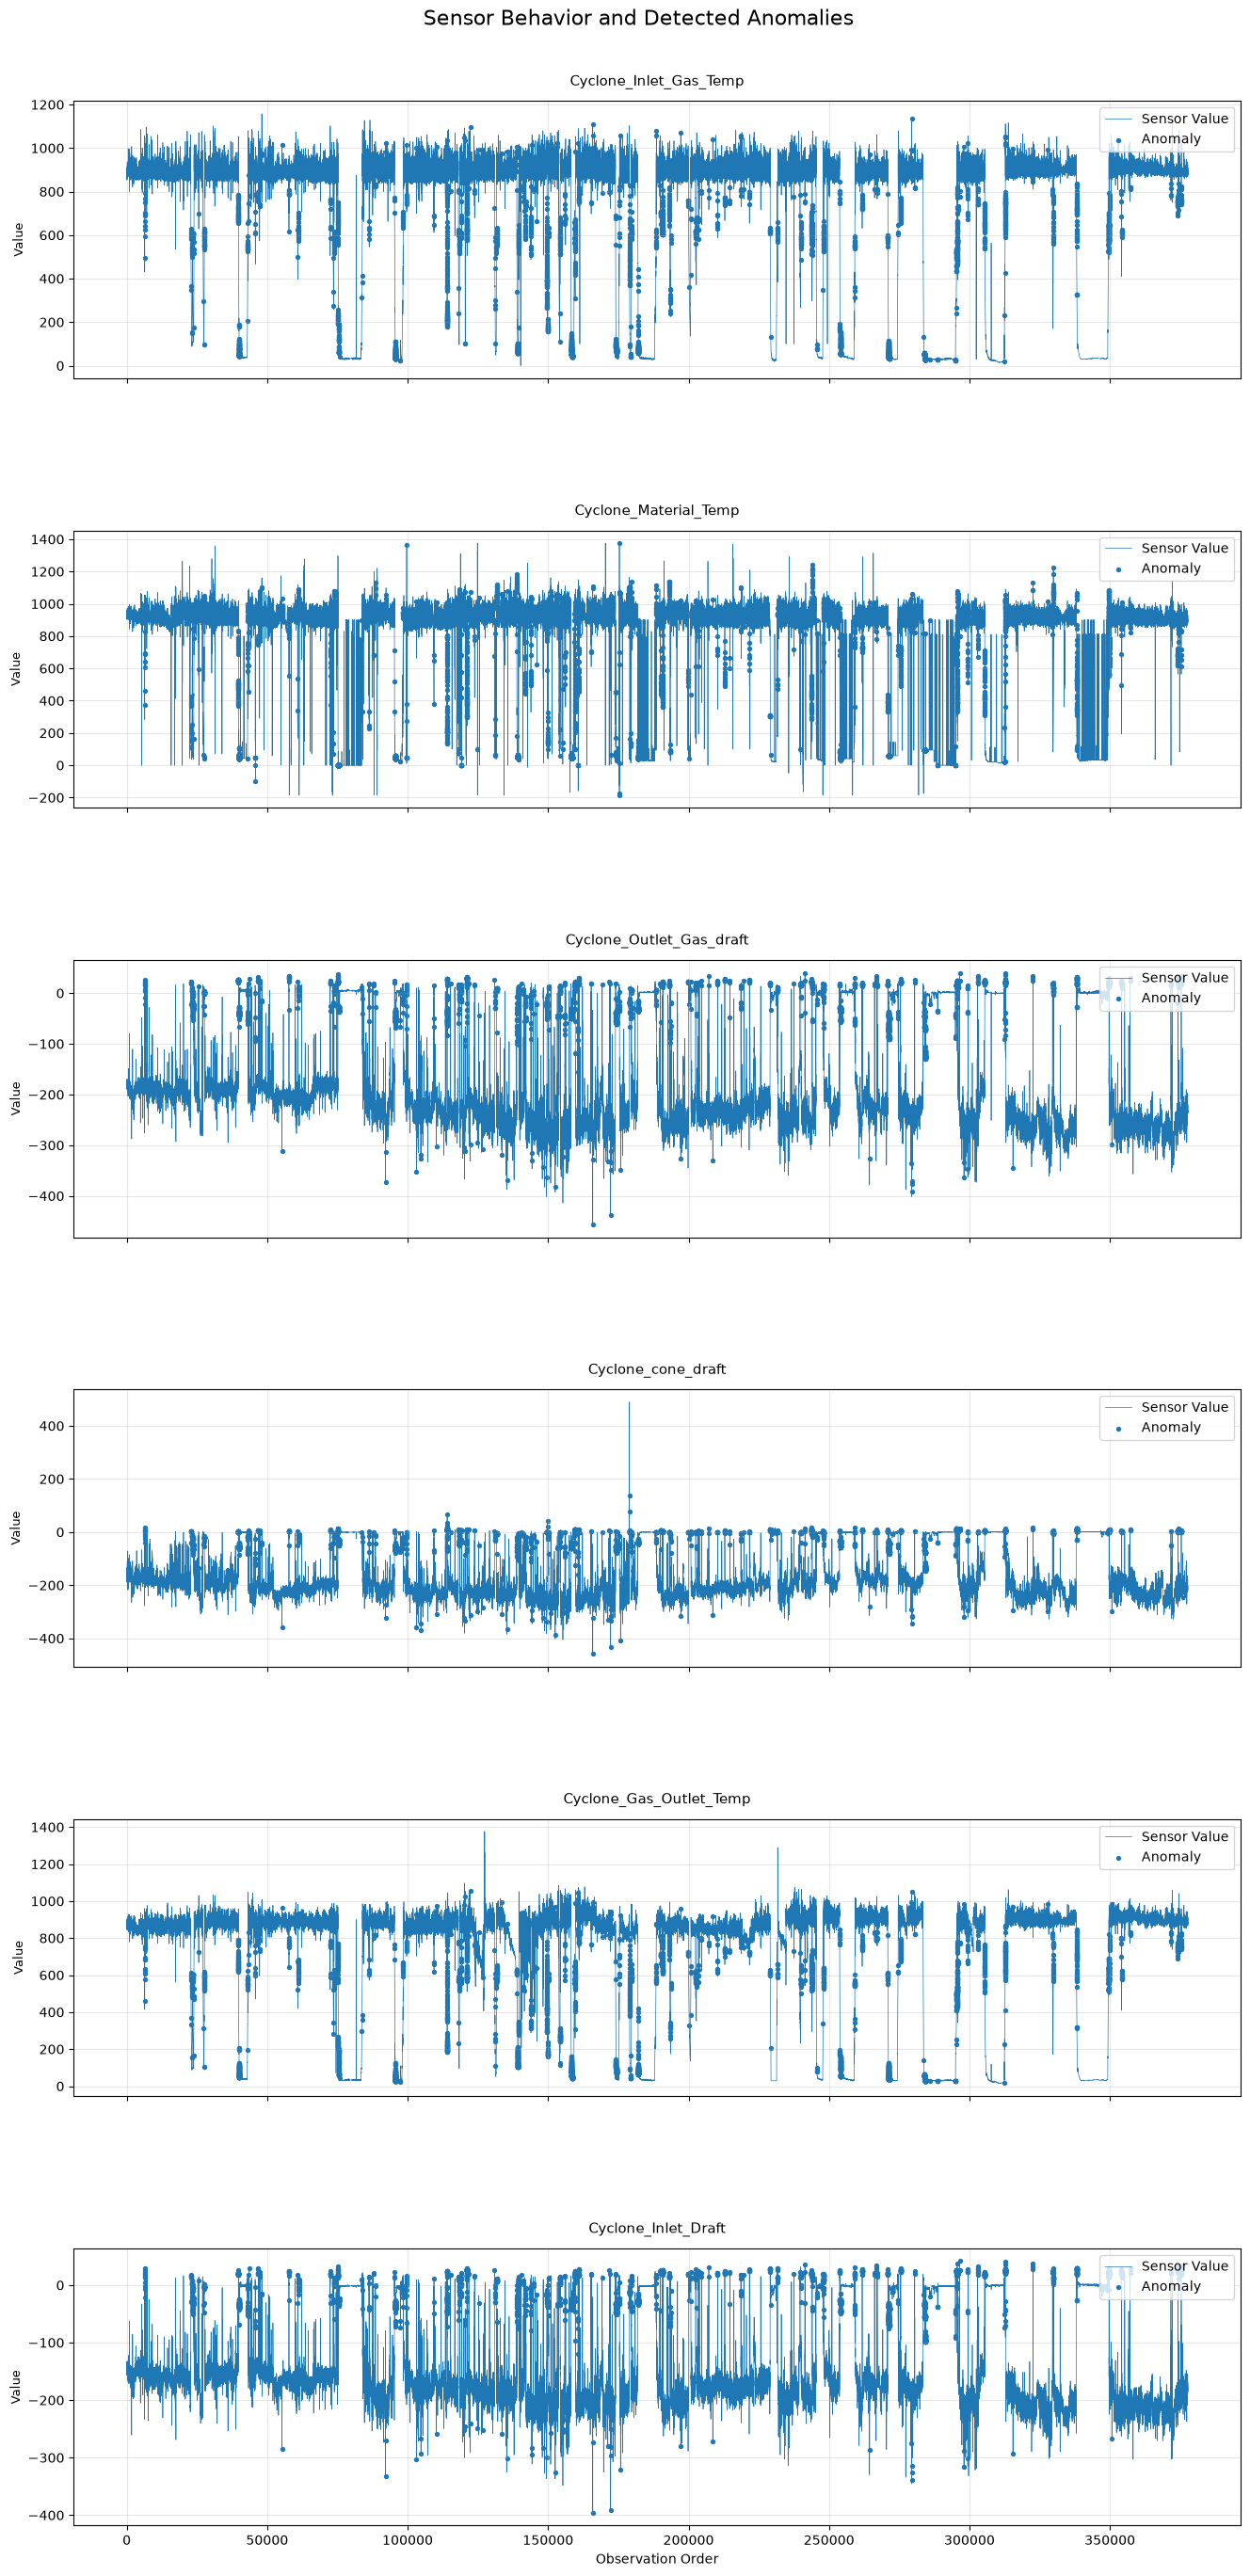

In [44]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a mask for the detected anomalous observations
anomaly_mask = analysis_df["anomaly"] == -1

# Create six vertically arranged line charts with more space
fig, axes = plt.subplots(
    6,
    1,
    figsize=(16, 28),
    sharex=True
)

# Plot each sensor separately
for ax, col in zip(axes, sensor_columns):

    # Plot the sensor values
    ax.plot(
        analysis_df.index,
        analysis_df[col],
        linewidth=0.5,
        label="Sensor Value"
    )

    # Highlight detected anomalies
    ax.scatter(
        analysis_df.index[anomaly_mask],
        analysis_df.loc[anomaly_mask, col],
        s=8,
        label="Anomaly"
    )

    # Add sensor name with some padding
    ax.set_title(
        col,
        fontsize=11,
        pad=12
    )

    # Add y-axis label
    ax.set_ylabel(
        "Value",
        fontsize=9
    )

    # Add grid
    ax.grid(
        True,
        alpha=0.3
    )

    # Add legend
    ax.legend(
        loc="upper right"
    )

# Add x-axis label to the last plot
axes[-1].set_xlabel(
    "Observation Order",
    fontsize=10
)

# Add overall title with extra space
fig.suptitle(
    "Sensor Behavior and Detected Anomalies",
    fontsize=16,
    y=0.995
)

# Increase vertical spacing between the six plots
plt.subplots_adjust(
    hspace=0.55,
    top=0.96,
    bottom=0.04
)

# Display the visualization
plt.show()

In [47]:
# Create the final abnormal-period table
final_periods = abnormal_periods[
    ["group", "anomaly_count", "start_time", "end_time"]
].copy()

# Rename the columns for clearer interpretation
final_periods.columns = [
    "Anomaly_Group",
    "Anomalous_Records",
    "Start_Time",
    "End_Time"
]

# Sort the groups by the number of anomalous records
final_periods = final_periods.sort_values(
    "Anomalous_Records",
    ascending=False
)

# Display the top 20 abnormal periods
print(
    final_periods.head(20).to_string(index=False)
)

 Anomaly_Group  Anomalous_Records       Start_Time         End_Time
           456                181 08-02-2019 10:25 08-03-2019 01:25
           102                173 11/28/2017 18:20  11/29/2017 8:40
            41                150  5/19/2017 20:35   5/20/2017 9:00
           246                124 07-05-2018 10:00 07-05-2018 20:15
           250                 98 07-06-2018 01:10 07-06-2018 09:15
           457                 94 08-03-2019 01:45 08-03-2019 09:30
           470                 90   9/17/2019 0:50   9/17/2019 8:15
           182                 81   4/30/2018 3:00   4/30/2018 9:40
           280                 80  8/29/2018 17:45   8/30/2018 0:20
           555                 72 05-01-2020 12:05 05-01-2020 18:00
           433                 70 06-03-2019 19:00 06-04-2019 00:45
           308                 63   9/26/2018 8:20  9/26/2018 13:30
           532                 61 12/24/2019 18:10 12/24/2019 23:10
           183                 54   4/30/2018 9:

In [49]:
# Display the total number of records used for anomaly detection
print("Records analyzed:", len(analysis_df))

# Display the number of detected anomalous observations
print("Anomalous observations:", len(anomalies))

# Display the percentage of anomalous observations
print("Anomaly percentage:", anomaly_percentage)

# Display the number of abnormal periods
print("Abnormal periods:", len(final_periods))

# Display the largest abnormal periods
print("\nTop 10 abnormal periods:")
print(
    final_periods.head(10).to_string(index=False)
)

Records analyzed: 376124
Anomalous observations: 3762
Anomaly percentage: 1.0002020610224287
Abnormal periods: 577

Top 10 abnormal periods:
 Anomaly_Group  Anomalous_Records       Start_Time         End_Time
           456                181 08-02-2019 10:25 08-03-2019 01:25
           102                173 11/28/2017 18:20  11/29/2017 8:40
            41                150  5/19/2017 20:35   5/20/2017 9:00
           246                124 07-05-2018 10:00 07-05-2018 20:15
           250                 98 07-06-2018 01:10 07-06-2018 09:15
           457                 94 08-03-2019 01:45 08-03-2019 09:30
           470                 90   9/17/2019 0:50   9/17/2019 8:15
           182                 81   4/30/2018 3:00   4/30/2018 9:40
           280                 80  8/29/2018 17:45   8/30/2018 0:20
           555                 72 05-01-2020 12:05 05-01-2020 18:00
